In [1]:
%matplotlib inline

import os

import pandas as pd

import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('style.mplstyle')

from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value

import scipy.stats as st
from scipy.optimize import minimize

In [6]:
import sys
sys.path.append("/Users/colinburke/research/quasarlf/pubtools")
os.chdir("/Users/colinburke/research/quasarlf/pubtools")

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_49491/1322907543.py:16: RuntimeWarning: divide by zero encountered in log10
  apparent_magnitudes = Mi + 5 * np.log10(cosmo.luminosity_distance(redshifts).to(u.pc).value / 10)


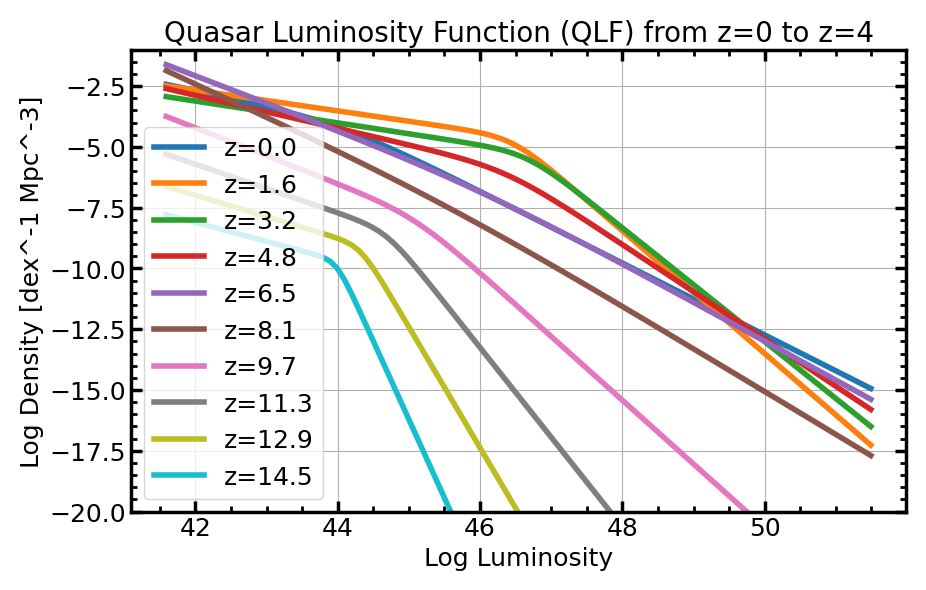

In [95]:
from utilities import return_bolometric_qlf

# Assuming the function to get the quasar LF is named `get_quasar_lf` in the utilities.py file

# Generate redshift values from 0 to 4
redshifts = np.linspace(0, 16, 100)

# Compute QLF for each redshift
qlf_values = [return_bolometric_qlf(redshift=z) for z in redshifts]

# Extract luminosity and density values
luminosities = qlf_values[0][0]  # Assuming luminosities are the same for all redshifts
Mi = 90 - 2.5*luminosities #TODO: K-correction
# Convert absolute magnitude Mi to apparent magnitude using redshift
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)  # Example cosmology, adjust as needed
apparent_magnitudes = Mi + 5 * np.log10(cosmo.luminosity_distance(redshifts).to(u.pc).value / 10)

# Extract densities for each redshift
densities = np.array([qlf[1] for qlf in qlf_values])


# Plot the QLF
plt.figure(figsize=(10, 6))
for i, z in enumerate(redshifts[::10]):  # Plot every 10th redshift for clarity
    plt.plot(luminosities, densities[i * 10], label=f'z={z:.1f}')
    #plt.plot(apparent_magnitudes, densities[i * 10], label=f'z={z:.1f} (apparent)')
plt.xlabel('Log Luminosity')
plt.ylabel('Log Density [dex^-1 Mpc^-3]')
plt.title('Quasar Luminosity Function (QLF) from z=0 to z=4')
plt.ylim(-20, -1)
plt.legend()
plt.grid()
plt.show()


In [96]:
len(np.trapz(densities, redshifts, axis=0))

100

/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_49491/850548204.py:30: RuntimeWarning: divide by zero encountered in log10
  plt.plot(luminosities[:-1], np.log10(total_densities), label='Total Densities')


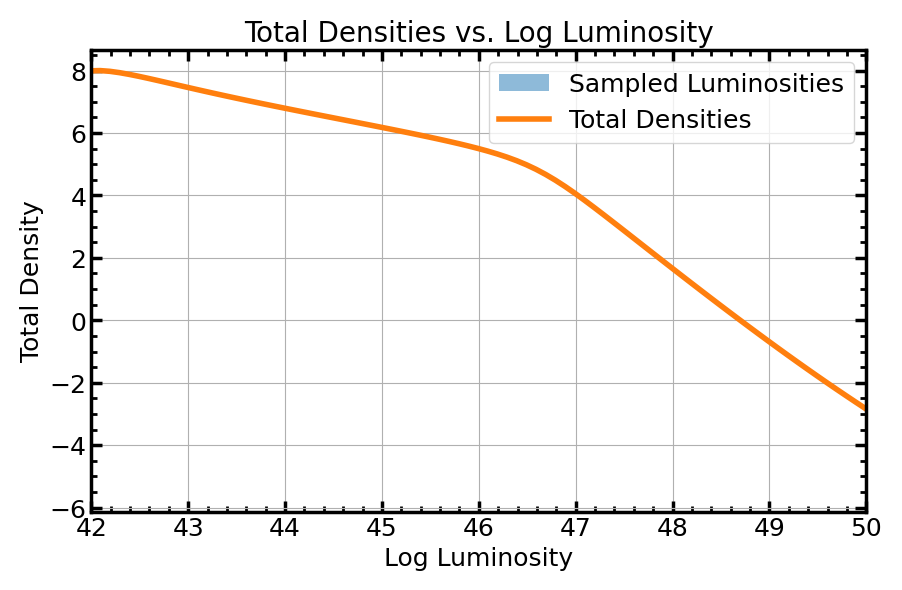

In [108]:
from scipy.interpolate import interp1d


# Integrate densities over redshift for each luminosity
total_densities = (np.trapz(10**densities, redshifts, axis=0)*cosmo.differential_comoving_volume(redshifts).value)[:-1] *np.diff(redshifts)

# Perform inverse transform sampling to sample from np.log10(total_densities)

# Ensure total_densities are positive for log10
positive_densities = np.log10(total_densities[total_densities > 0])
luminosities_positive = luminosities[:len(positive_densities)]

# Compute the cumulative distribution function (CDF)
cdf = np.cumsum(10**positive_densities)
cdf /= cdf[-1]  # Normalize to make it a proper CDF

# Create an interpolation function for the inverse CDF
inverse_cdf = interp1d(cdf, luminosities_positive, bounds_error=False, fill_value="extrapolate")

# Generate random samples from a uniform distribution
random_samples = np.random.uniform(0, 1, size=1000)

# Map the random samples through the inverse CDF to get samples
sampled_luminosities = inverse_cdf(random_samples)

plt.figure(figsize=(10, 6))

# Plot histogram of sampled luminosities
plt.hist(10**sampled_luminosities, bins=10, density=True, alpha=0.5, label='Sampled Luminosities')
plt.plot(luminosities[:-1], np.log10(total_densities), label='Total Densities')
plt.xlabel('Log Luminosity')
plt.ylabel('Total Density')
plt.title('Total Densities vs. Log Luminosity')
#plt.ylim(-80, -10)
plt.xlim(42, 50)
plt.legend()
plt.grid()
plt.show()

(array([0.77364264, 0.6992986 , 0.38798295, 0.22303211, 0.11848581,
        0.06969754, 0.02090926, 0.01626276, 0.01161626, 0.00232325]),
 array([41.55673024, 41.98716153, 42.41759282, 42.84802411, 43.2784554 ,
        43.70888669, 44.13931798, 44.56974927, 45.00018056, 45.43061185,
        45.86104314]),
 <BarContainer object of 10 artists>)

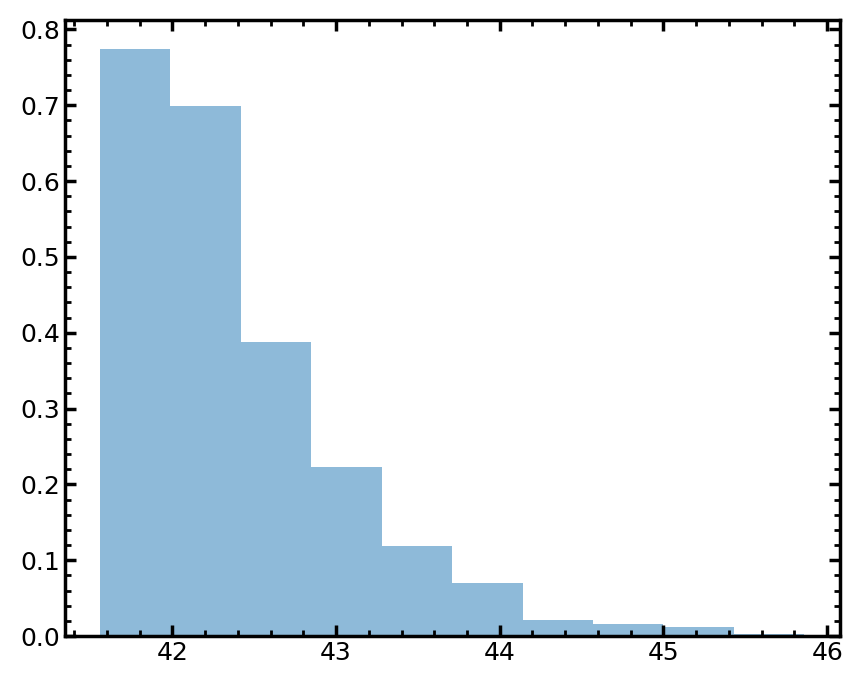

In [109]:
plt.hist(sampled_luminosities, bins=10, density=True, alpha=0.5, label='Sampled Luminosities')
